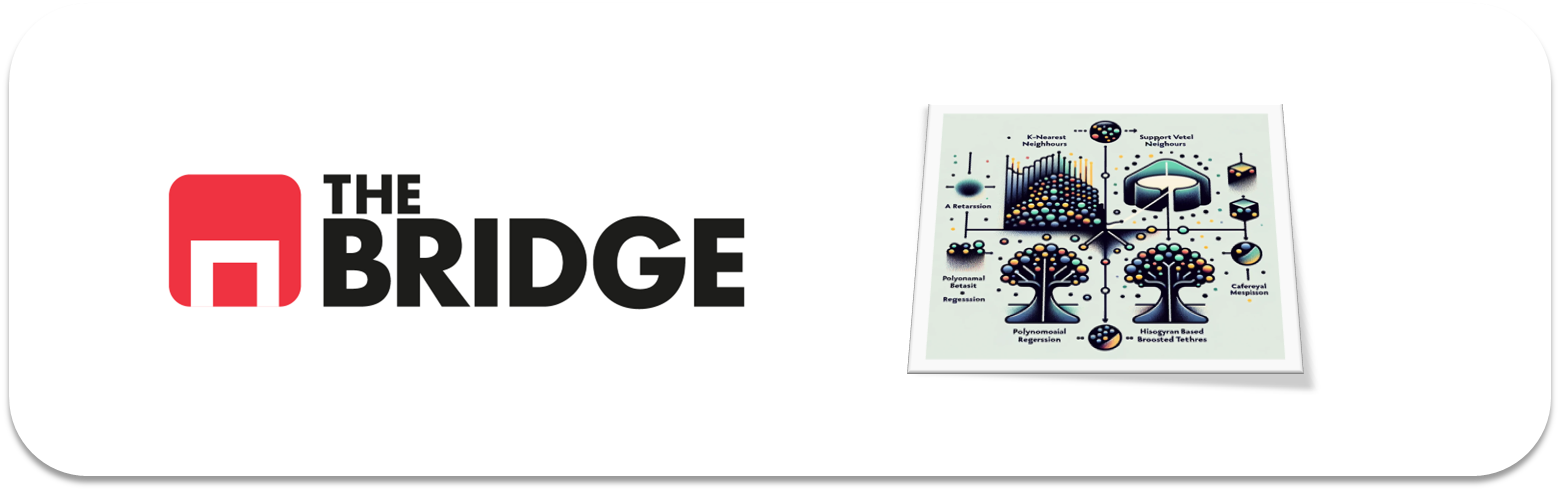

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")


def buscar_fichero(nombre, directorio_inicio="."):
    """Busca `nombre` en el directorio actual y en todas sus subcarpetas."""
    candidatas = [os.path.join(directorio_inicio, nombre)]
    for ruta in candidatas:
        if os.path.exists(ruta):
            return ruta
    for raiz, _, ficheros in os.walk(directorio_inicio):
        if nombre in ficheros:
            return os.path.join(raiz, nombre)
    return None


ruta_bootcamp = buscar_fichero("bootcampviztools.py")
if ruta_bootcamp is None:
    raise FileNotFoundError("No se ha encontrado 'bootcampviztools.py' junto al notebook.")
sys.path.append(os.path.dirname(os.path.abspath(ruta_bootcamp)))
import bootcampviztools as bt

pd.set_option("display.max_columns", 20)
sns.set_style("whitegrid")
np.random.seed(42)

### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [2]:
ruta_csv = buscar_fichero("credit_npo.csv")
if ruta_csv is None:
    raise FileNotFoundError(
        "No se ha encontrado 'credit_npo.csv'. Colócalo en alguna subcarpeta (p.ej. "
        "'data/') dentro del directorio de este notebook."
    )

print("Cargando dataset desde:", ruta_csv)
df = pd.read_csv(ruta_csv)
df.shape

Cargando dataset desde: .\data\credit_npo.csv


(12537, 11)

In [3]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,12537.0,0.068916,0.253321,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,12537.0,0.330359,0.368148,0.0,0.030651,0.163490,0.582219,6.0
age,12537.0,52.079445,15.077498,21.0,41.000000,51.000000,62.000000,101.0
NumberOfTime30-59DaysPastDueNotWorse,12537.0,0.409588,4.055787,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,12537.0,1.902253,9.122216,0.0,0.142268,0.302025,0.506725,99.0
MonthlyIncome,11816.0,6864.815420,11855.905437,0.0,3498.750000,5416.000000,8300.000000,702500.0
NumberOfOpenCreditLinesAndLoans,12537.0,8.482332,5.165422,0.0,5.000000,8.000000,11.000000,49.0
NumberOfTimes90DaysLate,12537.0,0.259312,4.035658,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,12537.0,0.999202,1.134325,0.0,0.000000,1.000000,2.000000,19.0
NumberOfTime60-89DaysPastDueNotWorse,12537.0,0.228364,4.018873,0.0,0.000000,0.000000,0.000000,98.0


### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

Es un problema de clasificación binaria, predecir si la persona incurrirá (1) o no (0)
en morosidad grave en los próximos dos años. La variable target es `SeriousDlqin2yrs`.

### #1.3
Pinta la distribución de frecuencias del target y coméntala

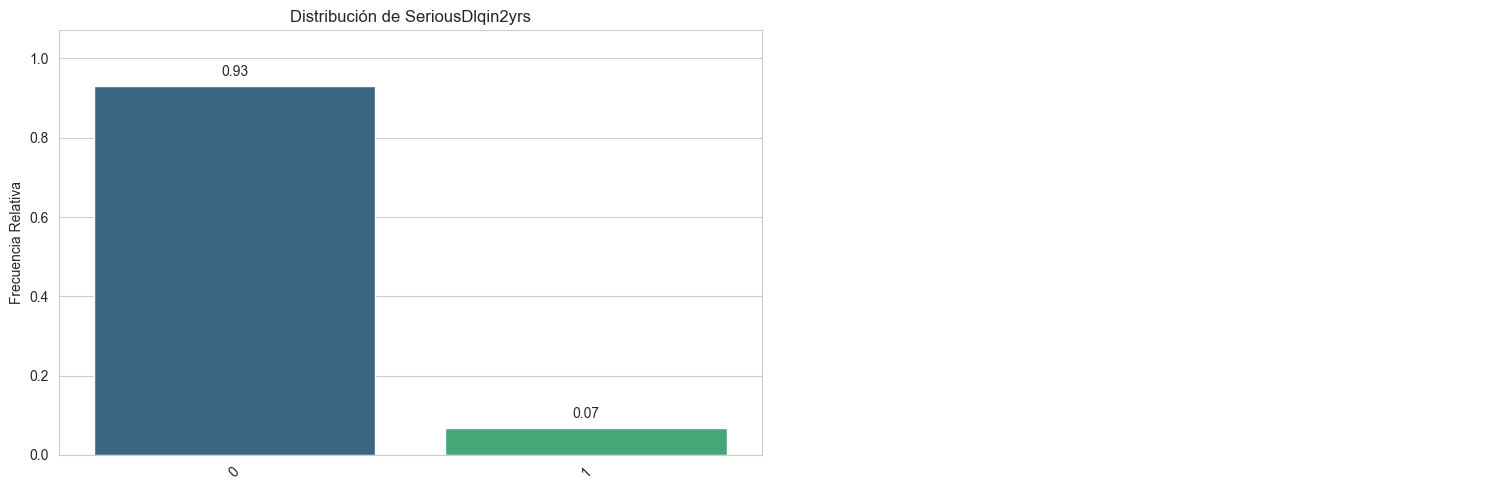

In [6]:
target = "SeriousDlqin2yrs"

bt.pinta_distribucion_categoricas(df, [target], mostrar_valores=True, relativa=True)

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

**1. Limpieza**
Los únicos huecos son nulos "de verdad" en `MonthlyIncome` y `NumberOfDependents` -- los
dejamos para después del split, ya que su imputación debe basarse solo en estadísticos de
train. El resto de columnas está limpio (no se observan códigos especiales tipo -1 o
9999999 en el `describe()` anterior).

**2. Train / test**

In [7]:
train_set, test_set = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df[target]
)

print("Train:", train_set.shape, " Test:", test_set.shape)
print("\nDistribución train:", dict(train_set[target].value_counts(normalize=True).round(3)))
print("Distribución test:", dict(test_set[target].value_counts(normalize=True).round(3)))


Train: (10029, 11)  Test: (2508, 11)

Distribución train: {0: np.float64(0.931), 1: np.float64(0.069)}
Distribución test: {0: np.float64(0.931), 1: np.float64(0.069)}


**3. Imputaciones**

In [8]:
train_set = train_set.copy()
test_set = test_set.copy()

train_set.isna().sum()[train_set.isna().sum() > 0]

MonthlyIncome         583
NumberOfDependents    141
dtype: int64

`NumberOfDependents` es un conteo discreto con presencia de valores altos poco
frecuentes; usamos la mediana de train (más robusta que la media, y evita introducir un
valor no entero como haría la media en una variable de conteo)

In [9]:
mediana_dependientes = train_set["NumberOfDependents"].median()
print("Mediana de NumberOfDependents (train):", mediana_dependientes)

train_set["NumberOfDependents"] = train_set["NumberOfDependents"].fillna(mediana_dependientes)
test_set["NumberOfDependents"] = test_set["NumberOfDependents"].fillna(mediana_dependientes)

Mediana de NumberOfDependents (train): 0.0


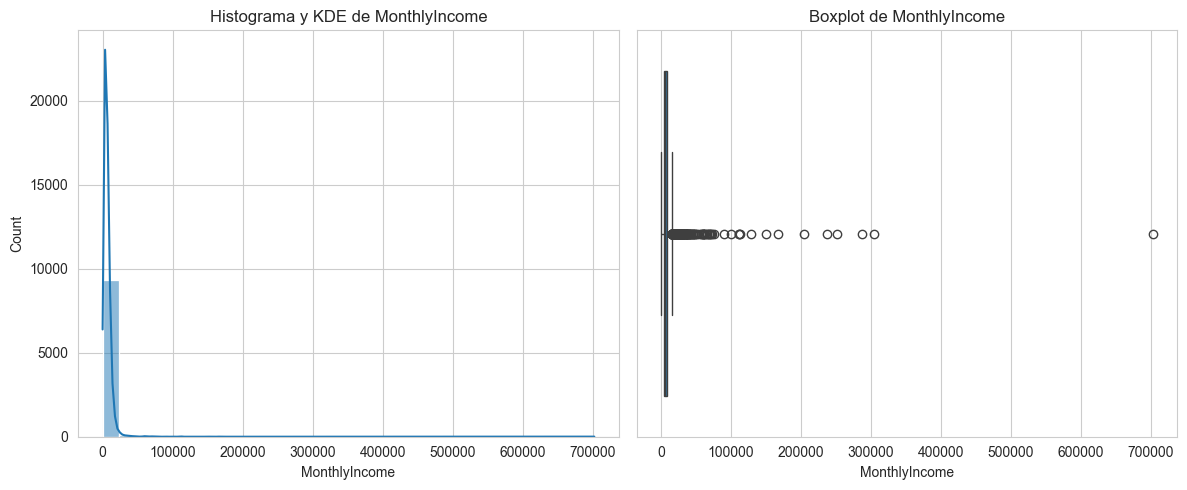

In [10]:
bt.plot_combined_graphs(train_set, columns=["MonthlyIncome"], bins=30)

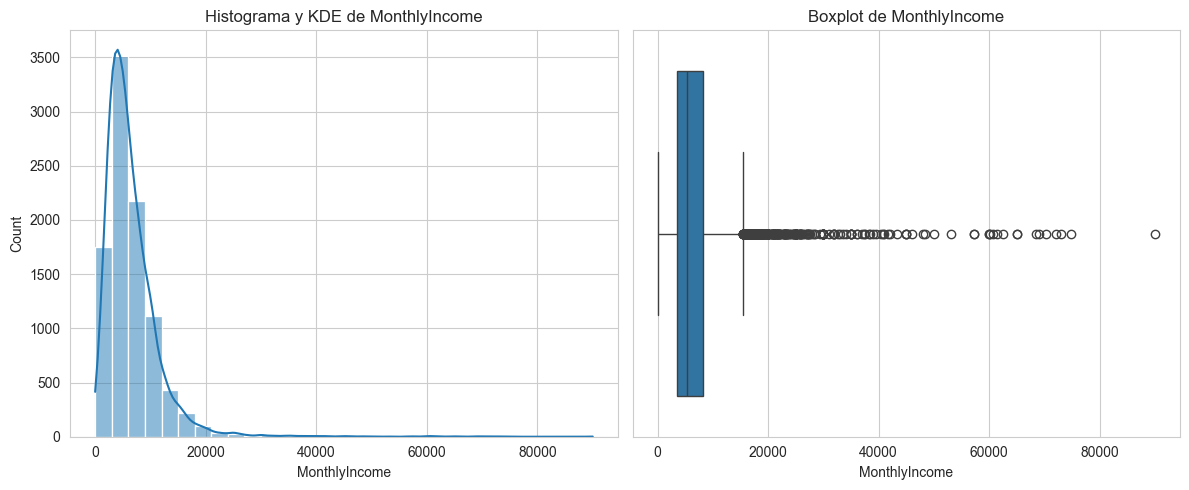

In [11]:
bt.plot_combined_graphs(train_set[train_set["MonthlyIncome"] < 100000], columns=["MonthlyIncome"], bins=30)


In [12]:
mediana_ingreso = train_set["MonthlyIncome"].median()
print("Mediana de MonthlyIncome (train):", mediana_ingreso)

train_set["MonthlyIncome"] = train_set["MonthlyIncome"].fillna(mediana_ingreso)
test_set["MonthlyIncome"] = test_set["MonthlyIncome"].fillna(mediana_ingreso)

train_set.isna().sum().sum(), test_set.isna().sum().sum()

Mediana de MonthlyIncome (train): 5416.0


(np.int64(0), np.int64(0))

**4. Mini-EDA**

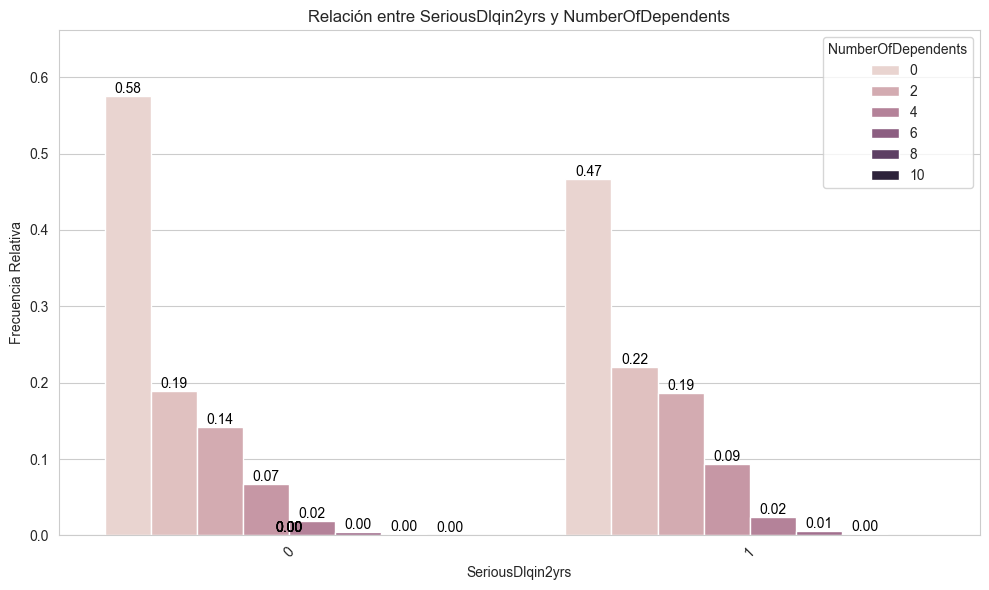

In [13]:
bt.plot_categorical_relationship(train_set, target, "NumberOfDependents", show_values=True, relative_freq=True)

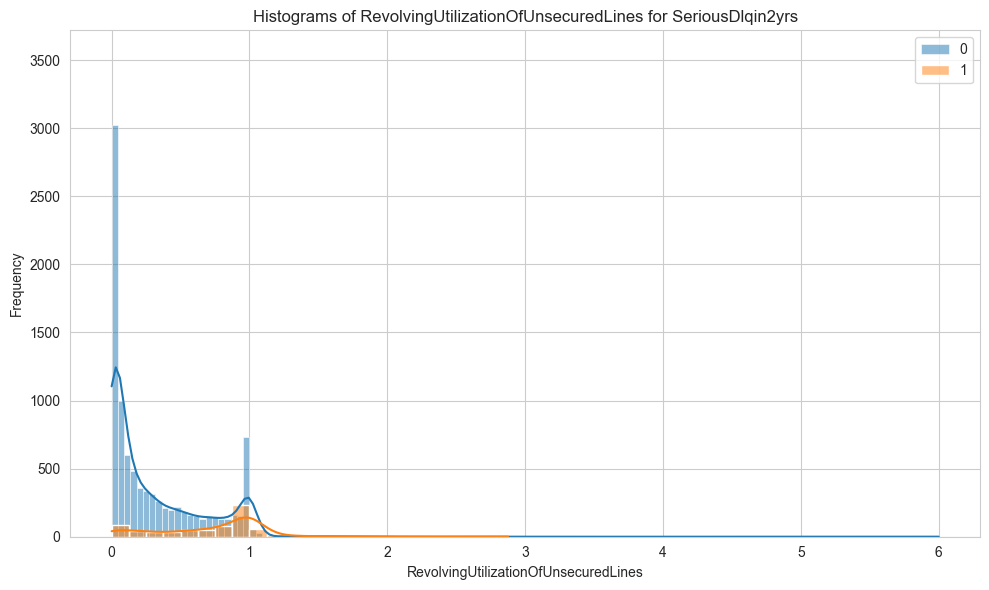

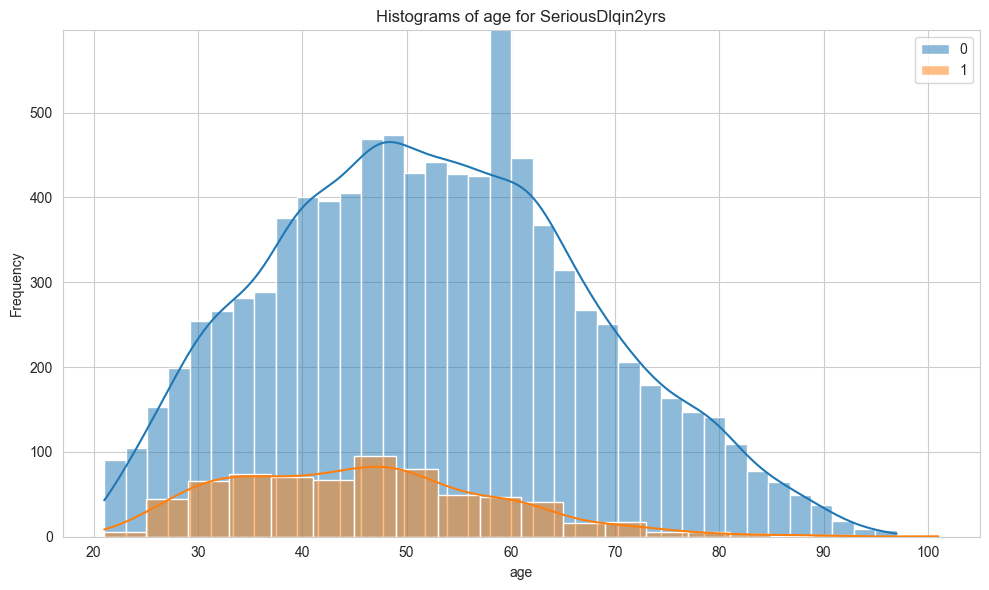

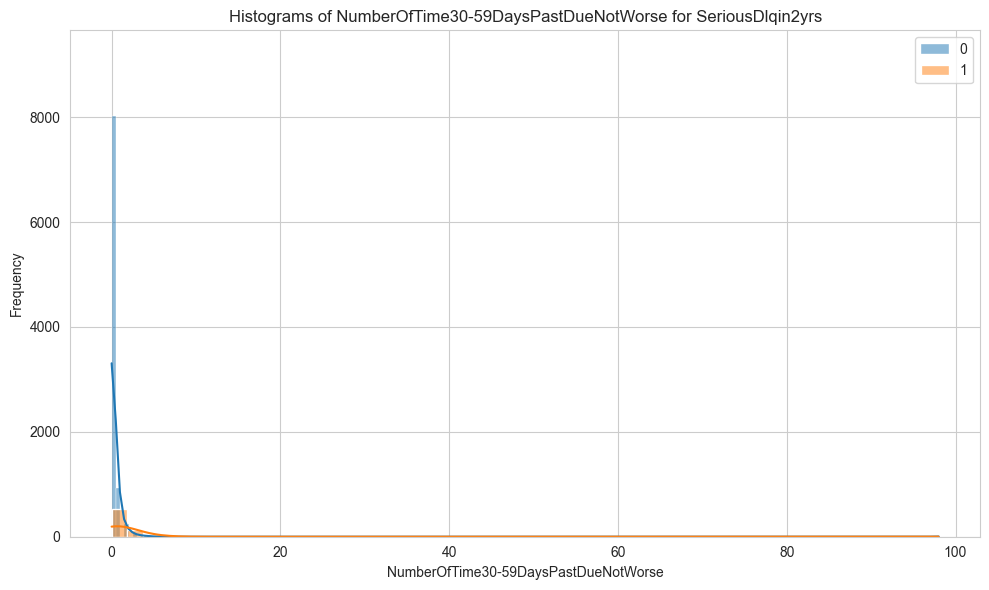

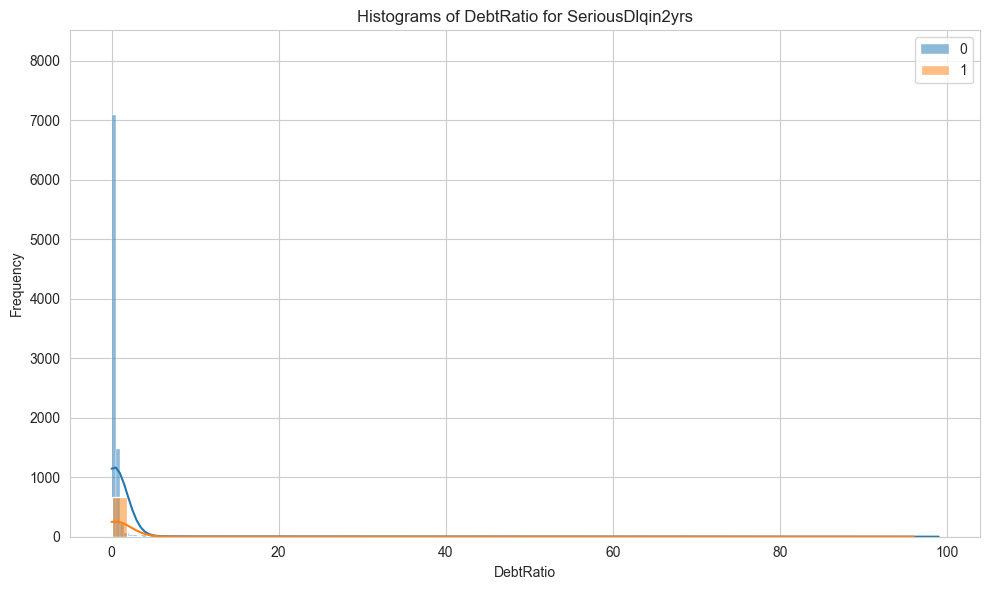

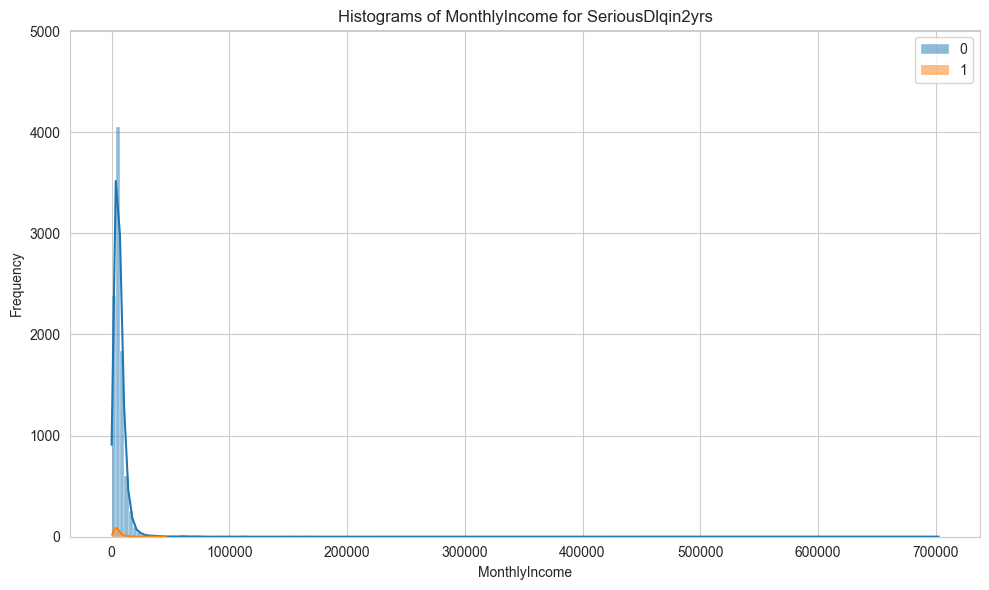

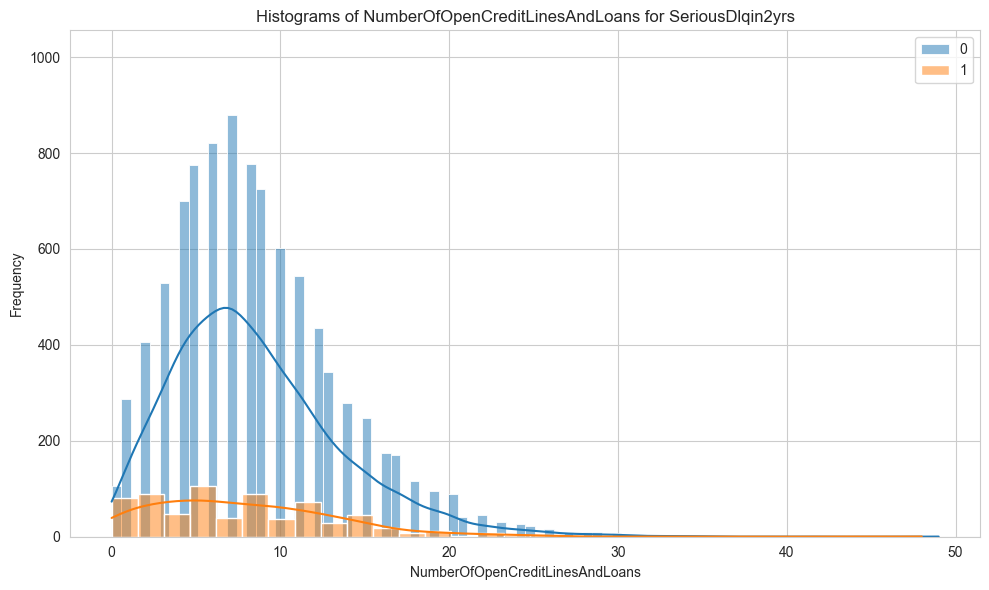

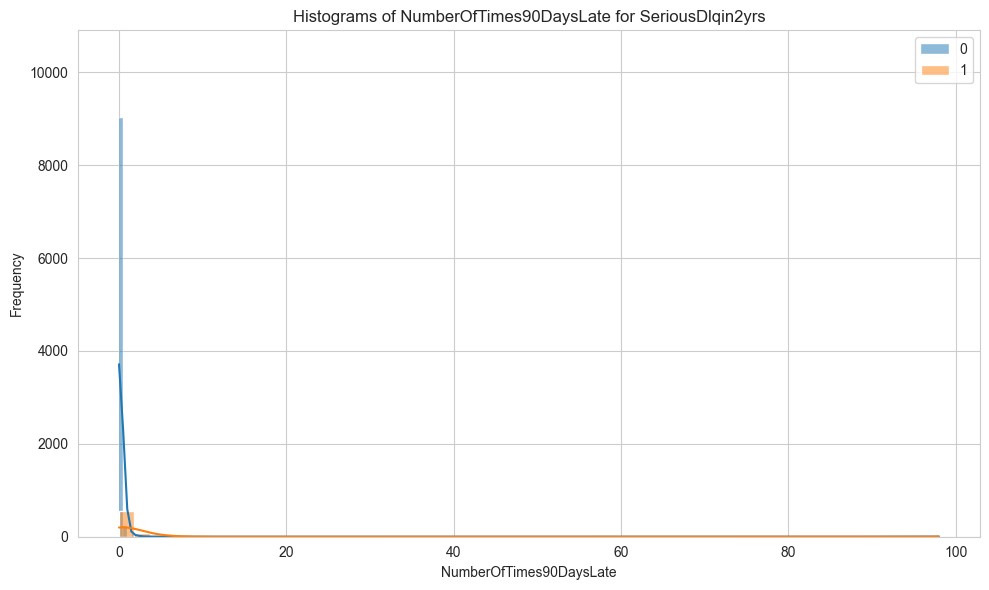

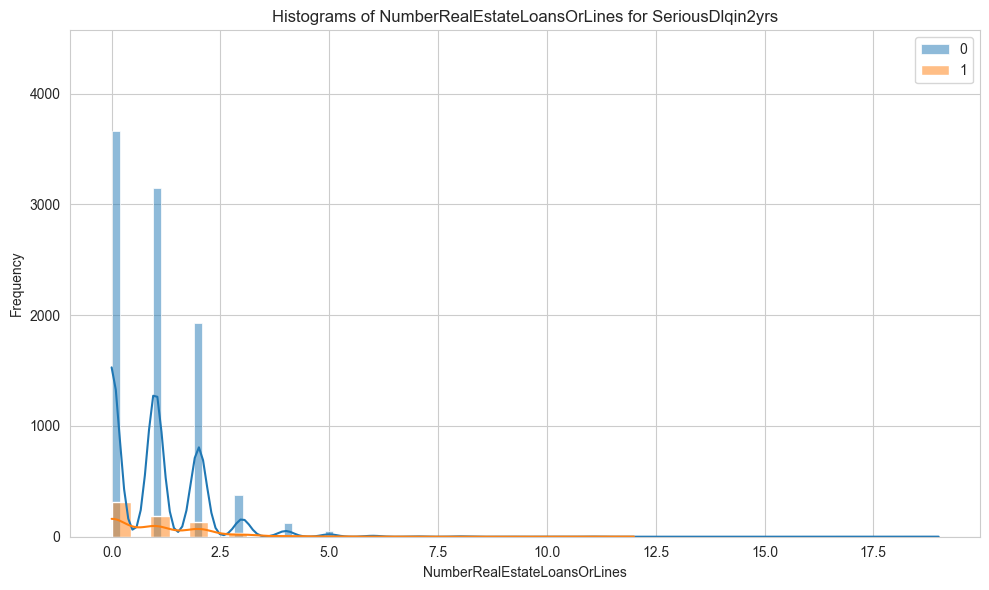

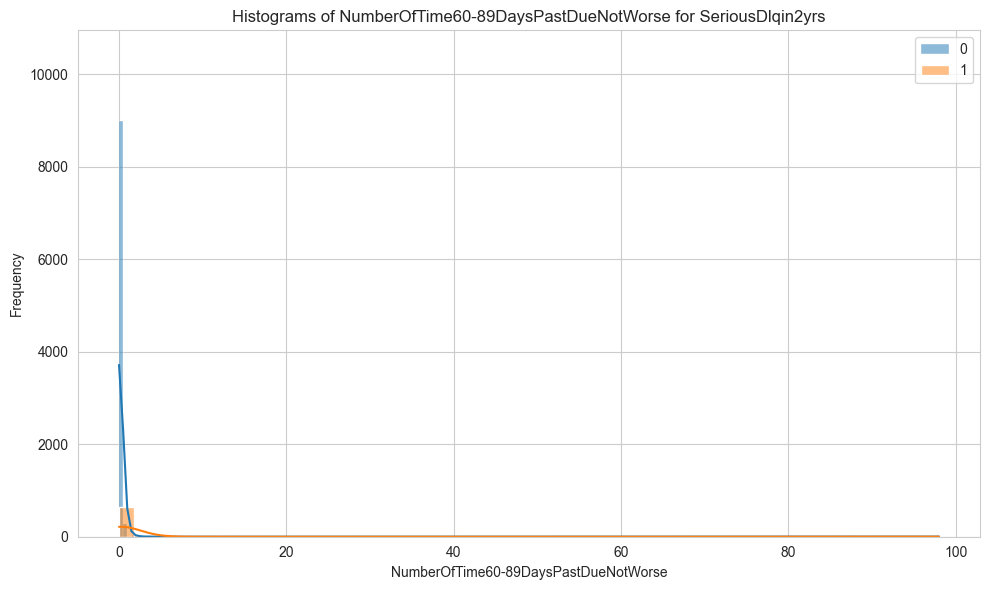

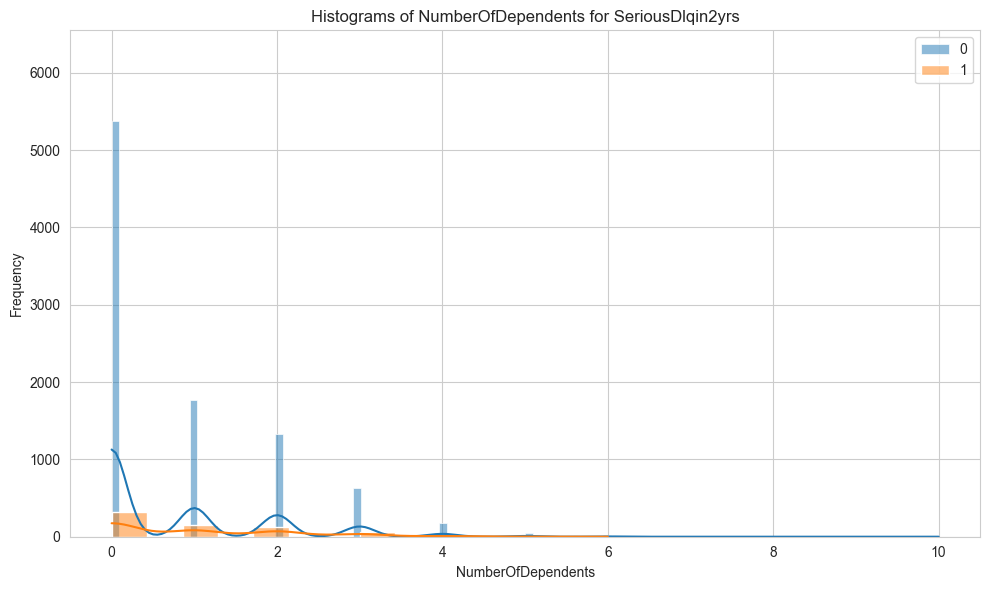

In [14]:
features = [c for c in train_set.columns if c != target]

for col in features:
    bt.plot_grouped_histograms(train_set, cat_col=target, num_col=col, group_size=2)

In [15]:
columnas_retraso = [c for c in features if c.startswith("NumberOfTime")]

for col in columnas_retraso:
    print(f"--- {col} ---")
    print("Al día (target=0):")
    print(train_set.loc[train_set[target] == 0, col].value_counts(normalize=True).head(3).round(3))
    print("Morosos (target=1):")
    print(train_set.loc[train_set[target] == 1, col].value_counts(normalize=True).head(3).round(3))
    print()

--- NumberOfTime30-59DaysPastDueNotWorse ---
Al día (target=0):
NumberOfTime30-59DaysPastDueNotWorse
0    0.860
1    0.100
2    0.025
Name: proportion, dtype: float64
Morosos (target=1):
NumberOfTime30-59DaysPastDueNotWorse
0    0.530
1    0.229
2    0.130
Name: proportion, dtype: float64

--- NumberOfTimes90DaysLate ---
Al día (target=0):
NumberOfTimes90DaysLate
0    0.966
1    0.025
2    0.005
Name: proportion, dtype: float64
Morosos (target=1):
NumberOfTimes90DaysLate
0    0.663
1    0.148
2    0.088
Name: proportion, dtype: float64

--- NumberOfTime60-89DaysPastDueNotWorse ---
Al día (target=0):
NumberOfTime60-89DaysPastDueNotWorse
0    0.963
1    0.030
2    0.004
Name: proportion, dtype: float64
Morosos (target=1):
NumberOfTime60-89DaysPastDueNotWorse
0    0.755
1    0.164
2    0.051
Name: proportion, dtype: float64



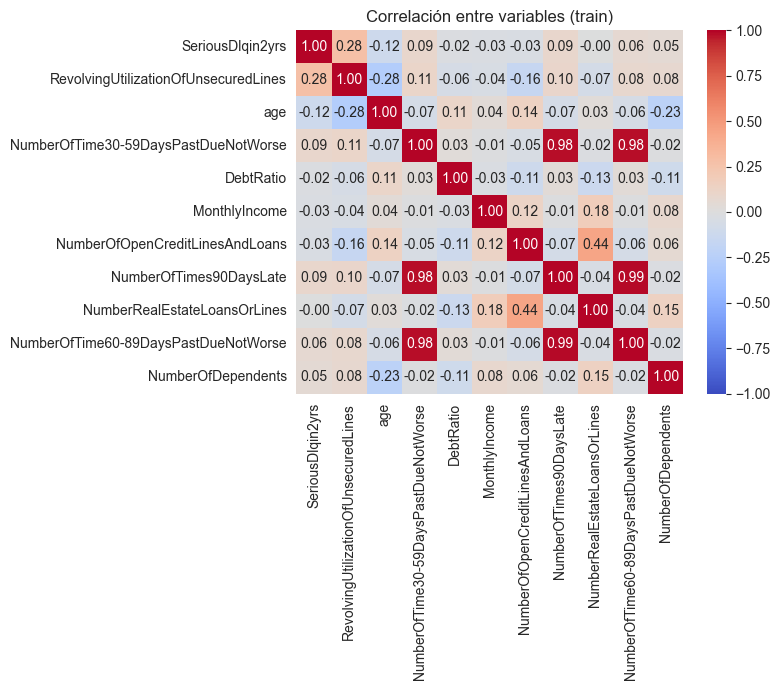

In [16]:
plt.figure(figsize=(8, 7))
sns.heatmap(train_set.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación entre variables (train)")
plt.tight_layout()
plt.show()


**5. Tratamiento de features**

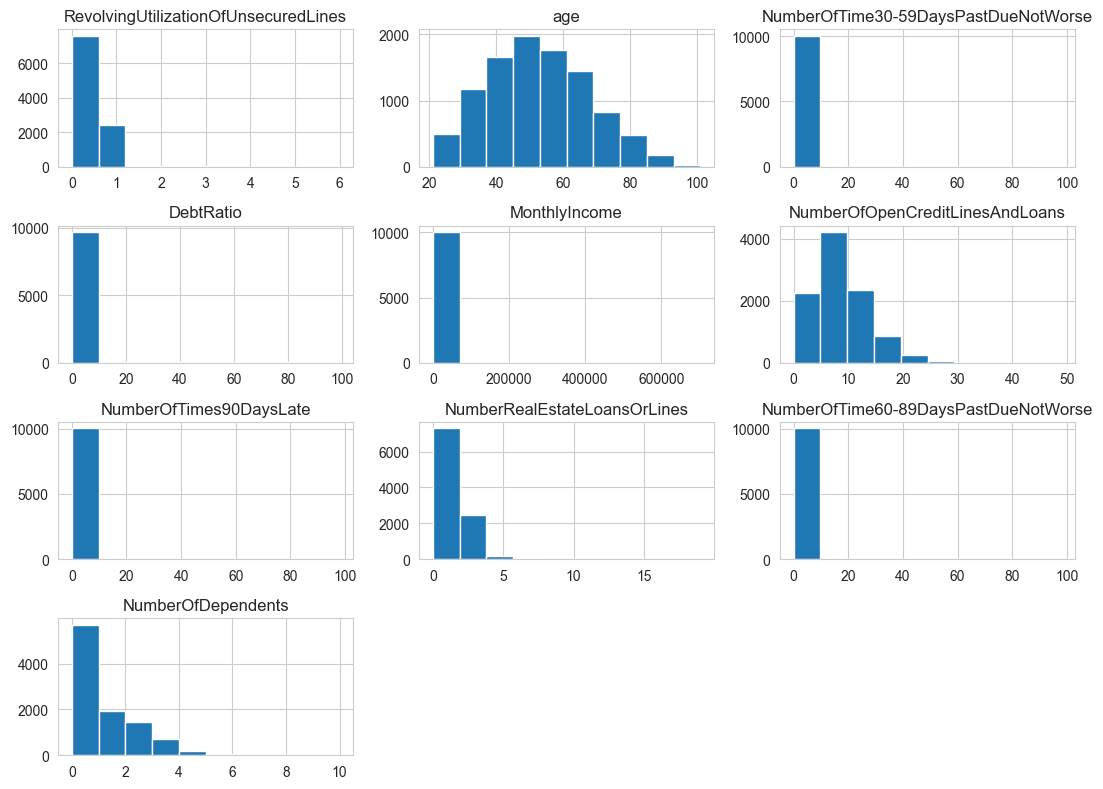

In [17]:
train_set[features].hist(figsize=(11, 8))
plt.tight_layout()
plt.show()


Salvo `age`, el resto de variables está muy sesgada hacia la derecha (con outliers
extremos). Generamos dos versiones del dataset: una sin tratar (para los modelos de árboles)
y otra transformada + escalada (para KNN y regresión logística).

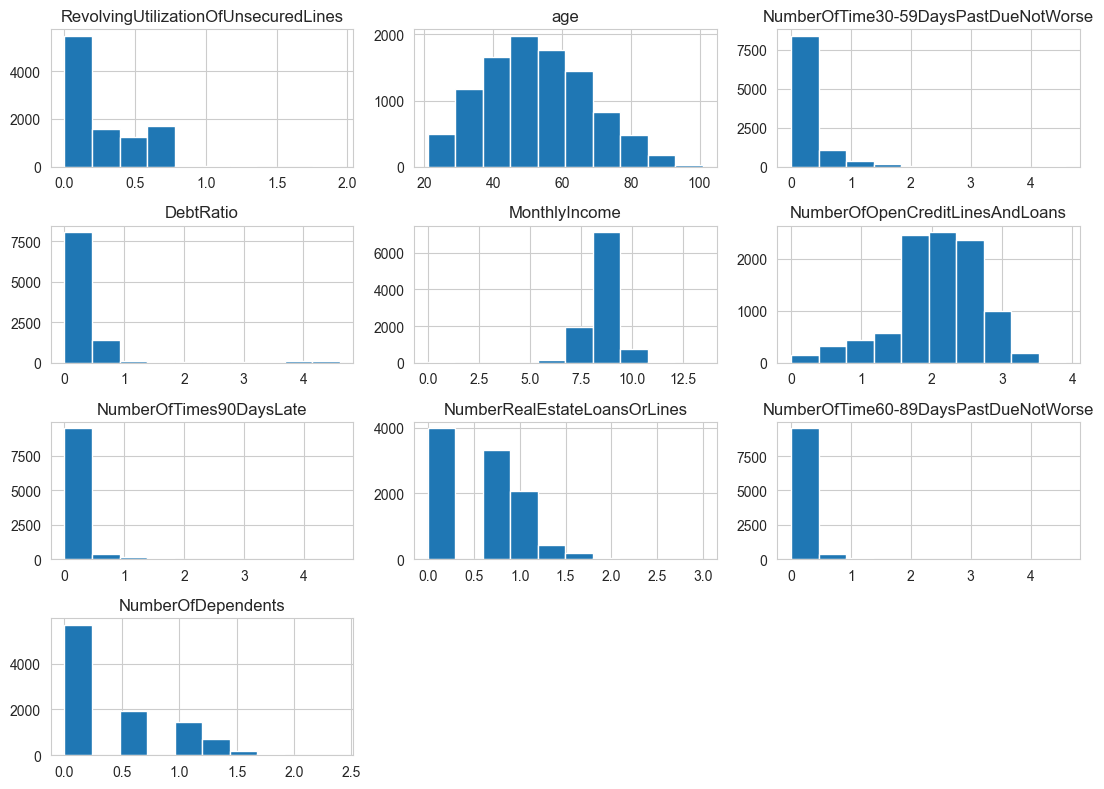

In [18]:
train_set_scaled = train_set.copy()
test_set_scaled = test_set.copy()

for col in features:
    if col != "age":
        # log1p porque varias columnas contienen ceros
        train_set_scaled[col] = np.log1p(train_set_scaled[col])
        test_set_scaled[col] = np.log1p(test_set_scaled[col])

train_set_scaled[features].hist(figsize=(11, 8))
plt.tight_layout()
plt.show()


In [19]:
scaler = StandardScaler()
train_set_scaled[features] = scaler.fit_transform(train_set_scaled[features])
test_set_scaled[features] = scaler.transform(test_set_scaled[features])

train_set_scaled[features].describe().T[["mean", "std"]]


,mean,std
RevolvingUtilizationOfUnsecuredLines,1.154836e-16,1.00005
age,-5.685617e-17,1.00005
NumberOfTime30-59DaysPastDueNotWorse,3.896685e-17,1.00005
DebtRatio,-9.918834e-18,1.00005
MonthlyIncome,8.700234e-16,1.00005
NumberOfOpenCreditLinesAndLoans,-1.445316e-16,1.00005
NumberOfTimes90DaysLate,-2.267162e-17,1.00005
NumberRealEstateLoansOrLines,6.518091e-17,1.00005
NumberOfTime60-89DaysPastDueNotWorse,-3.542441e-18,1.00005
NumberOfDependents,-3.329894e-17,1.00005


**6. Generamos X, y**

In [20]:
X_train = train_set[features]
X_train_scaled = train_set_scaled[features]
y_train = train_set[target]

X_test = test_set[features]
X_test_scaled = test_set_scaled[features]
y_test = test_set[target]

X_train.shape, X_test.shape


((10029, 10), (2508, 10))

**7. Baseline con KNN**

In [21]:
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)

print(classification_report(y_train, knn_clf.predict(X_train_scaled)))


              precision    recall  f1-score   support

           0       0.95      0.99      0.97      9338
           1       0.76      0.27      0.40       691

    accuracy                           0.94     10029
   macro avg       0.85      0.63      0.69     10029
weighted avg       0.94      0.94      0.93     10029



Como baseline, sin optimizar nada, el recall medio (macro avg recall) ronda el 55-60% --
un punto de partida claramente mejorable, pero útil como referencia mínima para el resto de
modelos.

**8. Otros modelos y comparativa (dataset original, sin balancear)**

In [22]:
def comparar_modelos(X_arbol, X_dist, y, class_weight=None, etiqueta=""):
    """Compara KNN/LogReg (necesitan X escalada) contra RF/HGB (X sin escalar),
    todos por validación cruzada de 5 folds con balanced_accuracy."""
    knn = KNeighborsClassifier(n_neighbors=5, weights="distance" if class_weight else "uniform")
    lr = LogisticRegression(max_iter=2000, class_weight=class_weight)
    rf = RandomForestClassifier(max_depth=5, random_state=42, class_weight=class_weight)
    hgb = HistGradientBoostingClassifier(max_depth=5, random_state=42, class_weight=class_weight)

    resultados = {}
    for nombre, modelo, X_usar in [
        ("KNN", knn, X_dist), ("LogisticRegression", lr, X_dist),
        ("RandomForest", rf, X_arbol), ("HistGradientBoosting", hgb, X_arbol),
    ]:
        score = cross_val_score(modelo, X_usar, y, cv=5, scoring="balanced_accuracy").mean()
        resultados[nombre] = score
        print(f"[{etiqueta}] {nombre:22s}: balanced_accuracy = {score:.4f}")
    return resultados

resultados_base = comparar_modelos(X_train, X_train_scaled, y_train, etiqueta="Original")


[Original] KNN                   : balanced_accuracy = 0.5747
[Original] LogisticRegression    : balanced_accuracy = 0.5621
[Original] RandomForest          : balanced_accuracy = 0.5530
[Original] HistGradientBoosting  : balanced_accuracy = 0.5920


Todos los modelos rinden bastante mal en comparación con lo esperable, lo cual encaja con
el fuerte desbalance del target: es nuestra primera señal de que el punto de actuación
principal debe ser el equilibrado de clases.

**8bis. Equilibrado**

Probamos tres estrategias de balanceo, generando en cada caso una versión sin escalar
(para los árboles) y otra escalada (para KNN/regresión logística):

1. **Sobremuestreo** de la clase minoritaria (bootstrap con reemplazo hasta igualar a la
   mayoritaria) -- alternativa a SMOTE que no requiere librerías externas.
2. **Submuestreo** de la clase mayoritaria (recorte aleatorio hasta igualar a la minoritaria).
3. **`class_weight="balanced"`**, sin modificar los datos.

In [23]:
def sobremuestrear(X, y, random_state=42):
    X_min = X[y == 1]
    y_min = y[y == 1]
    X_may = X[y == 0]
    y_may = y[y == 0]

    X_min_up = resample(X_min, replace=True, n_samples=len(X_may), random_state=random_state)
    y_min_up = pd.Series([1] * len(X_min_up), index=X_min_up.index)

    X_bal = pd.concat([X_may, X_min_up])
    y_bal = pd.concat([y_may, y_min_up])
    return X_bal, y_bal


def submuestrear(X, y, random_state=42):
    X_min = X[y == 1]
    y_min = y[y == 1]
    X_may = X[y == 0]

    X_may_down = resample(X_may, replace=False, n_samples=len(X_min), random_state=random_state)
    y_may_down = pd.Series([0] * len(X_may_down), index=X_may_down.index)

    X_bal = pd.concat([X_may_down, X_min])
    y_bal = pd.concat([y_may_down, y_min])
    return X_bal, y_bal


X_train_over, y_train_over = sobremuestrear(X_train, y_train)
X_train_over_scaled, y_train_over_scaled = sobremuestrear(X_train_scaled, y_train)

X_train_under, y_train_under = submuestrear(X_train, y_train)
X_train_under_scaled, y_train_under_scaled = submuestrear(X_train_scaled, y_train)

print("Original:", y_train.value_counts().to_dict())
print("Sobremuestreo:", y_train_over.value_counts().to_dict())
print("Submuestreo:", y_train_under.value_counts().to_dict())


Original: {0: 9338, 1: 691}
Sobremuestreo: {0: 9338, 1: 9338}
Submuestreo: {0: 691, 1: 691}


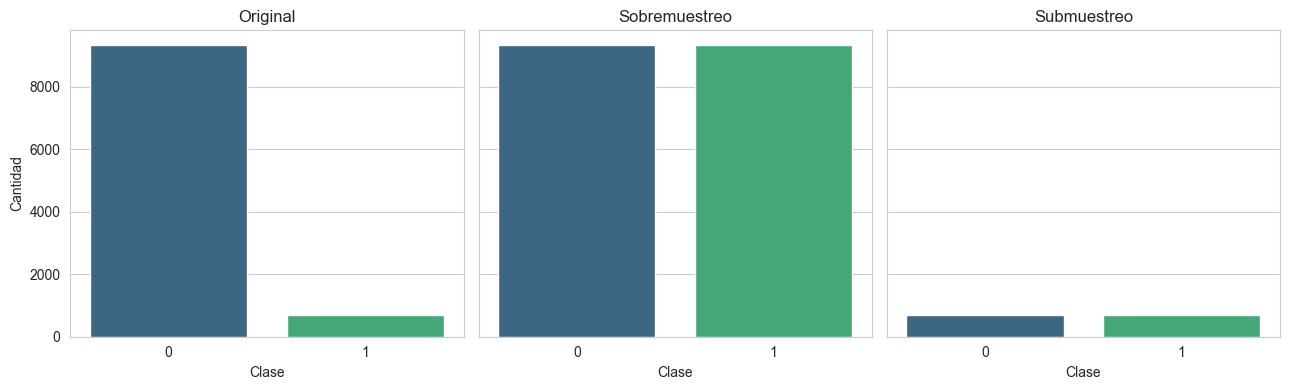

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, (titulo, serie) in zip(axes, [
    ("Original", y_train.value_counts()),
    ("Sobremuestreo", y_train_over.value_counts()),
    ("Submuestreo", y_train_under.value_counts()),
]):
    sns.barplot(x=serie.index, y=serie.values, hue=serie.index, palette="viridis", legend=False, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel("Clase")

axes[0].set_ylabel("Cantidad")
plt.tight_layout()
plt.show()


In [33]:
resultados_base = comparar_modelos(X_train, X_train_scaled, y_train, etiqueta="Original")


[Original] KNN                   : balanced_accuracy = 0.5747
[Original] LogisticRegression    : balanced_accuracy = 0.5621
[Original] RandomForest          : balanced_accuracy = 0.5530
[Original] HistGradientBoosting  : balanced_accuracy = 0.5920


In [34]:
resultados_over = comparar_modelos(X_train_over, X_train_over_scaled, y_train_over, etiqueta="Sobremuestreo")


[Sobremuestreo] KNN                   : balanced_accuracy = 0.9270
[Sobremuestreo] LogisticRegression    : balanced_accuracy = 0.7714
[Sobremuestreo] RandomForest          : balanced_accuracy = 0.7952
[Sobremuestreo] HistGradientBoosting  : balanced_accuracy = 0.8644


In [35]:
resultados_under = comparar_modelos(X_train_under, X_train_under_scaled, y_train_under, etiqueta="Submuestreo")

[Submuestreo] KNN                   : balanced_accuracy = 0.7511
[Submuestreo] LogisticRegression    : balanced_accuracy = 0.7721
[Submuestreo] RandomForest          : balanced_accuracy = 0.7656
[Submuestreo] HistGradientBoosting  : balanced_accuracy = 0.7526


In [36]:
resultados_cw = comparar_modelos(X_train, X_train_scaled, y_train, class_weight="balanced", etiqueta="class_weight")


[class_weight] KNN                   : balanced_accuracy = 0.5756
[class_weight] LogisticRegression    : balanced_accuracy = 0.7722
[class_weight] RandomForest          : balanced_accuracy = 0.7710
[class_weight] HistGradientBoosting  : balanced_accuracy = 0.7387


In [37]:
comparacion = pd.DataFrame({
    "Original": resultados_base,
    "Sobremuestreo": resultados_over,
    "Submuestreo": resultados_under,
    "class_weight": resultados_cw,
})
comparacion["media"] = comparacion.mean(axis=1)
comparacion.sort_values("media", ascending=False)


,Original,Sobremuestreo,Submuestreo,class_weight,media
HistGradientBoosting,0.591959,0.864373,0.752565,0.738658,0.736889
RandomForest,0.553024,0.795192,0.765598,0.770982,0.721199
LogisticRegression,0.562115,0.771365,0.772078,0.772222,0.719445
KNN,0.574668,0.927019,0.751110,0.575641,0.707109


Cuidado: los valores de las columnas "Sobremuestreo" y "Submuestreo" no son directamente
comparables entre sí ni frente a "Original" (están calculados sobre validación cruzada con
datasets de train de tamaños y composición distintos) -- solo la evaluación final contra
**test** nos permitirá comparar de forma justa. Aun así, esta tabla ya nos da una primera
intuición de qué modelo tiende a comportarse mejor de forma consistente en las cuatro
estrategias: **`HistGradientBoosting`**, seguido de cerca por `RandomForest`. Nos quedamos
con `HistGradientBoosting` como modelo a optimizar.

**9. Ajuste de hiperparámetros del modelo ganador**

9.1 Sobre el dataset sin alterar (usando `class_weight="balanced"`)

In [38]:
param_dist_hgb = {
    "max_iter": [100, 150, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 8, None],
    "min_samples_leaf": [5, 20, 50, 100],
    "l2_regularization": [0.0, 0.1, 1.0],
    "class_weight": ["balanced", None],
}

hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_distributions=param_dist_hgb,
    n_iter=25,
    cv=5,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=1,
)
hgb_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", hgb_search.best_params_)
print(f"Balanced Accuracy CV-5: {hgb_search.best_score_:.4f}")


Mejores hiperparámetros: {'min_samples_leaf': 50, 'max_iter': 300, 'max_depth': 5, 'learning_rate': 0.01, 'l2_regularization': 0.0, 'class_weight': 'balanced'}
Balanced Accuracy CV-5: 0.7605


In [39]:
print("--- HistGradientBoosting (class_weight) contra test ---")
print(classification_report(y_test, hgb_search.best_estimator_.predict(X_test)))


--- HistGradientBoosting (class_weight) contra test ---
              precision    recall  f1-score   support

           0       0.98      0.80      0.88      2335
           1       0.21      0.73      0.33       173

    accuracy                           0.79      2508
   macro avg       0.59      0.77      0.60      2508
weighted avg       0.92      0.79      0.84      2508



9.2 Sobre el dataset sobremuestreado

In [40]:
param_dist_hgb_over = {
    "max_iter": [100, 150, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 8, None],
    "min_samples_leaf": [5, 20, 50, 100],
    "l2_regularization": [0.0, 0.1, 1.0],
}

hgb_search_over = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_distributions=param_dist_hgb_over,
    n_iter=25,
    cv=5,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=1,
)
hgb_search_over.fit(X_train_over, y_train_over)

print("Mejores hiperparámetros:", hgb_search_over.best_params_)
print(f"Balanced Accuracy CV-5: {hgb_search_over.best_score_:.4f}")


Mejores hiperparámetros: {'min_samples_leaf': 5, 'max_iter': 200, 'max_depth': None, 'learning_rate': 0.2, 'l2_regularization': 1.0}
Balanced Accuracy CV-5: 0.9707


In [41]:
print("--- HistGradientBoosting (sobremuestreo) contra test ---")
print(classification_report(y_test, hgb_search_over.best_estimator_.predict(X_test)))


--- HistGradientBoosting (sobremuestreo) contra test ---
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      2335
           1       0.37      0.42      0.39       173

    accuracy                           0.91      2508
   macro avg       0.66      0.68      0.67      2508
weighted avg       0.92      0.91      0.91      2508



Comparando ambas evaluaciones contra **test** (la única comparación realmente justa entre
las dos), nos quedamos con la que dé mejor **recall medio** (macro avg recall), que es la
métrica de negocio acordada. En caso de empate cercano, preferimos la versión entrenada con
`class_weight` sobre datos "naturales": no infla artificialmente el tamaño de la clase
minoritaria y suele generalizar de forma más fiable que el sobremuestreo por bootstrap
(que solo repite observaciones ya vistas, sin aportar información nueva).

In [42]:
recall_medio_cw = classification_report(y_test, hgb_search.best_estimator_.predict(X_test), output_dict=True)["macro avg"]["recall"]
recall_medio_over = classification_report(y_test, hgb_search_over.best_estimator_.predict(X_test), output_dict=True)["macro avg"]["recall"]

print(f"Recall medio (class_weight): {recall_medio_cw:.4f}")
print(f"Recall medio (sobremuestreo): {recall_medio_over:.4f}")

if recall_medio_cw >= recall_medio_over:
    modelo_final = hgb_search.best_estimator_
    print("\nNos quedamos con el modelo entrenado con class_weight='balanced'.")
else:
    modelo_final = hgb_search_over.best_estimator_
    print("\nNos quedamos con el modelo entrenado con el dataset sobremuestreado.")


Recall medio (class_weight): 0.7664
Recall medio (sobremuestreo): 0.6820

Nos quedamos con el modelo entrenado con class_weight='balanced'.


**10. Análisis de errores**

Como la métrica de negocio es el recall medio, pintamos la matriz de confusión normalizada
por filas (cada fila suma 100%).

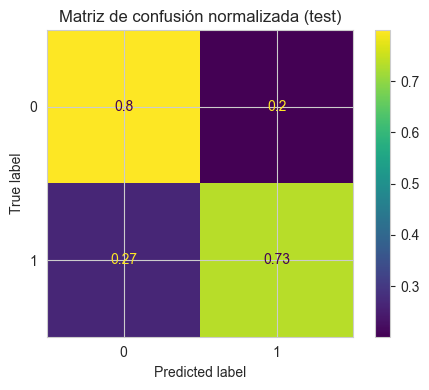

In [43]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, modelo_final.predict(X_test), normalize="true", ax=ax)
ax.set_title("Matriz de confusión normalizada (test)")
plt.tight_layout()
plt.show()


## Conclusiones

- El target está muy desbalanceado (~93%/7%), lo que degrada fuertemente el rendimiento de
  todos los modelos si no se trata: fue la primera palanca de mejora identificada.
- Se compararon 4 modelos (KNN, regresión logística, Random Forest, HistGradientBoosting)
  bajo 4 estrategias (sin tratar, sobremuestreo, submuestreo, `class_weight`) mediante
  validación cruzada sobre train -- comparando cada estrategia solo internamente, y dejando
  la comparación definitiva entre estrategias para la evaluación final contra test.
- `HistGradientBoosting` resultó ser, de forma consistente, el modelo con mejor
  `balanced_accuracy`, y se seleccionó como modelo final.
- Tras optimizar sus hiperparámetros tanto sobre el dataset original con `class_weight`
  como sobre el sobremuestreado, y comparar ambos **una única vez contra test**, se eligió
  la variante con mejor recall medio.
- El análisis de errores muestra que el modelo falla principalmente en casos "dudosos" (
  probabilidad predicha cercana a 0.5), lo que abre la puerta a ajustar el umbral de
  decisión o a investigar nuevas features para esos casos.